In [2]:
import glob
from skimage import io
import matplotlib.pyplot as plt
import cv2
import tifffile as tiff
import numpy as np
import rawpy
import imageio.v3 as iio
import os
from skimage.color import rgb2gray
from pathlib import Path

## 0. Check Image Version

In [37]:
import imagecodecs
print("imagecodecs version:", imagecodecs.__version__)
# Not all wheels expose a helper, but if present:
print("jpegxl available:", hasattr(imagecodecs, "jpegxl_decode"))

imagecodecs version: 2024.12.30
jpegxl available: True


## 1. Test trial with one image

In [9]:
import tifffile as tiff
import numpy as np
from skimage.color import rgb2gray
import imageio.v3 as iio
from pathlib import Path
# Import the necessary denoising functions from scikit-image
from skimage.restoration import denoise_nl_means, estimate_sigma

def convert_and_denoise_dng(dng_path, tiff_path):
    """
    Converts a DNG to a 16-bit grayscale TIFF and applies Non-Local Means
    denoising to remove fixed-pattern sensor noise.
    """
    print(f"Processing {Path(dng_path).name}...")
    try:
        # 1. Read the DNG file to get the processed RGB image.
        rgb_uint16 = tiff.imread(dng_path)
        print(f"Loaded RGB data: {rgb_uint16.shape}, {rgb_uint16.dtype}")

        # 2. Convert to a linear grayscale float image [0.0, 1.0].
        rgb_float = rgb_uint16.astype(np.float32) / 65535.0
        gray_float = rgb2gray(rgb_float)

        # 3. Denoise the image to remove sensor artifacts. ✅
        # First, estimate the noise level from the image.
        sigma_est = np.mean(estimate_sigma(gray_float, channel_axis=None))

        # Second, apply the NL-Means filter.
        # The 'h' parameter controls the strength of the filter.
        gray_denoised = denoise_nl_means(
            gray_float,
            h=0.8 * sigma_est,
            fast_mode=True,
            patch_size=5,       # Size of the patches used for comparison
            patch_distance=6    # Maximum distance to search for similar patches
        )

        # 4. Scale the clean float image back to the 16-bit integer range.
        gray_16bit = (gray_denoised * 65535).astype(np.uint16)

        # 5. Save the final, clean image.
        iio.imwrite(tiff_path, gray_16bit)
        print(f"Successfully denoised and saved to {Path(tiff_path).name}")

    except Exception as e:
        print(f"An error occurred: {e}")

# --- Example Usage ---
src = "../_images/20250829_001448.dng"
dst = "../_images/20250829_001448_denoised.tif"

convert_and_denoise_dng(src, dst)

Processing 20250829_001448.dng...
Loaded RGB data: (12240, 16320, 3), uint16
Successfully denoised and saved to 20250829_001448_denoised.tif


In [ ]:
src = "../_images/capillary.dng"
dst = "../_images/capillary.tif"

def convert_dng_to_tiff_final(dng_path, out_tif):
    arr = tiff.imread(dng_path)  # shape (H, W, 3), dtype=uint16
    print("Loaded:", arr.shape, arr.dtype)

    gray = rgb2gray(arr.astype(np.float32) / np.iinfo(arr.dtype).max)

    gray = cv2.GaussianBlur(gray, (0, 0), 0.5)

    iio.imwrite(out_tif, (gray * 65535).astype(np.uint16))
    print("Saved:", out_tif)

convert_dng_to_tiff_final(src, dst)

Loaded: (4284, 5712, 3) uint16
Saved: ../_images/capillary.tif


In [ ]:
src = "../_images/10-31-2025/20251101_032124.dng"
dst = "../_images/10-31-2025/20251101_032124_1.tif"

def convert_dng_to_tiff_final(dng_path, out_tif):
    arr = tiff.imread(dng_path)  # shape (H, W, 3), dtype=uint16
    print("Loaded:", arr.shape, arr.dtype)
    gray = rgb2gray(arr.astype(np.float32) / np.iinfo(arr.dtype).max)
    iio.imwrite(out_tif, (gray * 65535).astype(np.uint16))
    print("Saved:", out_tif)

convert_dng_to_tiff_final(src, dst)

<tifffile.TiffTag 274 @130> raised ValueError('0 is not a valid ORIENTATION')


Loaded: (3000, 4000, 3) uint16
Saved: ../_images/10-31-2025/20251101_032124_1.tif


In [5]:
import tifffile as tiff
import imageio.v3 as iio
import numpy as np
import os
from pathlib import Path

def convert_dng_to_green_tiff(dng_path, out_tif):
    """
    Loads a DNG file, extracts the raw 16-bit green channel,
    and saves it as a 16-bit grayscale TIFF.
    """
    try:
        # Load the demosaiced RGB image from the DNG
        arr = tiff.imread(dng_path)
        
        if arr.ndim != 3 or arr.shape[2] != 3:
            print(f"  [SKIP] Expected RGB, got {arr.shape}. ({dng_path.name})")
            return

        green_channel_data = arr[:, :, 1]
        iio.imwrite(out_tif, green_channel_data)
        
        print(f"  [OK] Saved: {out_tif.name}")

    except Exception as e:
        print(f"  [ERROR] Failed to process {dng_path.name}: {e}")



In [1]:
import tifffile as tiff
import numpy as np
import imageio.v3 as iio
from pathlib import Path

def convert_dng_to_linear_green_tiff_quant(dng_path, out_tif):
    """
    Loads the DNG, extracts the raw IFD, and applies black/white level 
    linearization, then extracts the green channel pixels.
    """
    try:
        with tiff.TiffFile(dng_path) as tif:
            # 1. Identify the RAW IFD (usually the last or highest resolution)
            if not tif.series:
                print(f"  [ERROR] No image series found in {dng_path.name}")
                return

            # Prioritize the "raw" image IFD
            raw_ifd = tif.pages[-1] 
            
            # Read the raw data array
            arr = raw_ifd.asarray()
            
            # 2. Check for required DNG metadata for linearization
            # BlackLevel and WhiteLevel are crucial for Beer's Law accuracy
            black_level = raw_ifd.tags.get('BlackLevel', None)
            white_level = raw_ifd.tags.get('WhiteLevel', None)
            
            if black_level is None or white_level is None:
                print("  [WARN] Missing BlackLevel or WhiteLevel tags. Using default 0 and 65535.")
                black = 0
                white = 65535
            else:
                # BlackLevel is often an array, take the mean or max, 
                # but for simplicity, we assume one value if it's a 2D array (Bayer)
                black = black_level.value[0] if isinstance(black_level.value, tuple) else black_level.value
                white = white_level.value

        # --- Linearization and Green Channel Extraction ---
        if arr.ndim == 2:
            # This is the 2D Bayer pattern array (the 'rawest' data)
            
            # LINEARIZATION: subtract black level and clip to the valid range
            linear_arr = arr.astype(np.float64) - black
            linear_arr = np.clip(linear_arr, 0, white - black)

            # Extract the two interleaved Green channels (Assuming RGGB/GBRG pattern)
            # You will need to determine your specific pattern (tif.pages[].tags.get('CFAPattern'))
            # Common patterns: G at (0,1) and (1,0) OR G at (0,0) and (1,1)
            
            # Option 1: Extract and average the two G channels
            G1 = linear_arr[0::2, 1::2] # Green in Row 0, Col 1 position
            G2 = linear_arr[1::2, 0::2] # Green in Row 1, Col 0 position
            green_channel_data = (G1 + G2) / 2
            
            # Rescale back to 16-bit range (0-65535) for saving
            max_val = white - black
            green_channel_data = (green_channel_data / max_val * 65535).astype(np.uint16)

        elif arr.ndim == 3 and arr.shape[2] == 3:
            # This is a linear RGB array (already demosaiced, but not gamma corrected)
            # Linearity should be preserved if the DNG writer followed the spec, 
            # but subtraction is still required if BlackLevel is non-zero.
            print("  [NOTE] Reading linear 3D array. Assuming linearization is pre-applied.")
            green_channel_data = arr[:, :, 1]
            
        else:
            print(f"  [SKIP] Unexpected array shape {arr.shape}.")
            return
            
        # Save the linear 16-bit data
        iio.imwrite(out_tif, green_channel_data)
        
        print(f"  [SUCCESS] Saved RAW linear green channel: {out_tif.name}")
        print("  This file contains intensity values corrected for Black Level, suitable for Beer's Law.")

    except Exception as e:
        print(f"  [FATAL ERROR] Failed to process {dng_path.name} (JXL issue likely): {e}")
        # If this fails, the JXL data block is unreadable by tifffile.
        print("\n*** NEXT STEPS IF THIS SCRIPT FAILS ***")
        print("Your Python environment cannot decode the JXL-compressed DNG raw data.")
        print("You must use an external tool to convert the DNG *first*.")
        print("1. **Adobe DNG Converter**: Use this free tool, set compatibility to a lower version (e.g., Camera Raw 12.4 or earlier), and it will convert the JXL DNG into a standard, readable DNG or TIFF with the raw data intact.")
        print("2. Run the script on the new DNG/TIFF file.")

# Example usage (adjust paths as needed):
# dng_file = Path("20251105_035809.dng")
# tif_file = Path("20251105_035809_linear_green.tif")
# convert_dng_to_linear_green_tiff_quant(dng_file, tif_file)

In [14]:
import tifffile as tiff
import imageio.v3 as iio
import numpy as np
from pathlib import Path

def flatten_nested_iterable(iterable):
    """Recursively flattens a deeply nested iterable (tuple, list, array)."""
    for element in iterable:
        if isinstance(element, (list, tuple, np.ndarray)):
            yield from flatten_nested_iterable(element)
        else:
            yield element

def get_linear_green_data(dng_path):
    """
    Forces tifffile to read the raw IFD via index, robustly linearizes the data, 
    and extracts the green channel.
    """
    try:
        with tiff.TiffFile(dng_path) as tif:
            # 1. Target the raw sensor data IFD using the last page's index
            raw_ifd_index = len(tif.pages) - 1
            
            # Read the array using the index (safest method for tifffile)
            arr = tif.asarray(series=raw_ifd_index) 
            
            # Get the page object again to access tags reliably
            raw_ifd = tif.pages[raw_ifd_index] 
            
            # --- Essential Linearization Metadata ---
            black_tag = raw_ifd.tags.get('BlackLevel')
            white_tag = raw_ifd.tags.get('WhiteLevel')
            
            # Robustly determine Black Level and White Level
            if black_tag is None or white_tag is None:
                black_val = 0.0
                white_val = 65535.0
                print("  [WARN] Missing BlackLevel/WhiteLevel tags. Using default 0 and 65535.")
            else:
                black = black_tag.value
                white = white_tag.value
                
                # FIX: Use the new flattening utility to ensure black_val is a single scalar.
                black_values = list(flatten_nested_iterable(black))
                white_values = list(flatten_nested_iterable(white))

                # Calculate the mean black level across all color planes
                if black_values:
                    black_val = float(np.mean(black_values))
                else:
                    black_val = 0.0

                # Use the first white level value, which should be the sensor max
                white_val = float(white_values[0]) if white_values else 65535.0

            # --- 1. Linearization: Subtract Black Level ---
            linear_arr = arr.astype(np.float64) - black_val
            linear_arr = np.clip(linear_arr, 0, white_val - black_val)

            # --- 2. Green Channel Extraction ---
            if linear_arr.ndim == 2:
                # 2D Bayer pattern: extract and average the two G channels
                G1 = linear_arr[0::2, 1::2] 
                G2 = linear_arr[1::2, 0::2]
                green_channel_data = (G1 + G2) / 2
            elif linear_arr.ndim == 3 and linear_arr.shape[2] == 3:
                # 3D linear RGB: extract the central green channel
                green_channel_data = linear_arr[:, :, 1]
            else:
                 raise ValueError(f"Unexpected data shape for processing: {linear_arr.shape}")
                
            # --- 3. Final Scaling and Format ---
            max_val = white_val - black_val
            if max_val <= 0:
                max_val = 1
            
            # Scale to 0-65535 and convert to 16-bit integer
            rescaled_data = (green_channel_data / max_val * 65535).astype(np.uint16)
            
            return rescaled_data
            
    except Exception as e:
        # Re-raising the original exception for context
        raise e

def convert_dng_to_linear_green_png(dng_path, out_png):
    """
    Converts a DNG to a linear, 16-bit grayscale PNG.
    """
    try:
        green_data = get_linear_green_data(dng_path)
        iio.imwrite(out_png, green_data)
        print(f"  [OK] Saved LINEAR 16-bit green channel PNG: {out_png.name}")
        
    except Exception as e:
        # The 'ORIENTATION' warning is usually harmless; only report the fatal error.
        print(f"  [ERROR] Failed to process {dng_path.name}: {e}")

In [15]:
# --- Set your source and destination folders here ---
src_folder = Path("../_images/11042025_S1_F(1)_1-750")
dst_folder = Path("../_images/11042025_S1_F(1)_1-750_green_png")


# Create the destination folder if it doesn't exist
dst_folder.mkdir(exist_ok=True)
print(f"Source: {src_folder}")
print(f"Destination: {dst_folder}\n")

dng_files = list(src_folder.glob("*.dng"))

if not dng_files:
    print("No .dng files found in the source folder.")
else:
    print(f"Found {len(dng_files)} DNG files. Starting conversion...")

for dng_path in dng_files:
    out_name = dng_path.stem + "_green.png"
    out_tif_path = dst_folder / out_name
    
    print(f"Processing: {dng_path.name}")

    if out_tif_path.exists():
        print(f"  [SKIP] Output file already exists. ({out_name})")
        continue
    
    convert_dng_to_linear_green_png(dng_path, out_tif_path)

print("\nBatch processing complete.")

<tifffile.TiffTag 274 @130> raised ValueError('0 is not a valid ORIENTATION')


Source: ../_images/11042025_S1_F(1)_1-750
Destination: ../_images/11042025_S1_F(1)_1-750_green_png

Found 10 DNG files. Starting conversion...
Processing: 20251105_035821.dng


<tifffile.TiffTag 274 @130> raised ValueError('0 is not a valid ORIENTATION')


  [OK] Saved LINEAR 16-bit green channel PNG: 20251105_035821_green.png
Processing: 20251105_035759.dng


<tifffile.TiffTag 274 @130> raised ValueError('0 is not a valid ORIENTATION')


...

  [OK] Saved LINEAR 16-bit green channel PNG: 20251105_035802_green.png
Processing: 20251105_035813.dng


<tifffile.TiffTag 274 @130> raised ValueError('0 is not a valid ORIENTATION')


  [OK] Saved LINEAR 16-bit green channel PNG: 20251105_035813_green.png
Processing: 20251105_035755.dng


<tifffile.TiffTag 274 @130> raised ValueError('0 is not a valid ORIENTATION')


  [OK] Saved LINEAR 16-bit green channel PNG: 20251105_035755_green.png
Processing: 20251105_035806.dng
  [OK] Saved LINEAR 16-bit green channel PNG: 20251105_035806_green.png

Batch processing complete.


In [11]:
# --- Set your source and destination folders here ---
src_folder = Path("../_images/11042025_S2_F(3)_1-350")
dst_folder = Path("../_images/11042025_S2_F(3)_1-350_green_tiff")


# Create the destination folder if it doesn't exist
dst_folder.mkdir(exist_ok=True)
print(f"Source: {src_folder}")
print(f"Destination: {dst_folder}\n")

dng_files = list(src_folder.glob("*.dng"))

if not dng_files:
    print("No .dng files found in the source folder.")
else:
    print(f"Found {len(dng_files)} DNG files. Starting conversion...")

for dng_path in dng_files:
    out_name = dng_path.stem + "_green.tif"
    out_tif_path = dst_folder / out_name
    
    print(f"Processing: {dng_path.name}")

    if out_tif_path.exists():
        print(f"  [SKIP] Output file already exists. ({out_name})")
        continue
    
    convert_dng_to_green_tiff(dng_path, out_tif_path)

print("\nBatch processing complete.")

Source: ../_images/11042025_S2_F(3)_1-350
Destination: ../_images/11042025_S2_F(3)_1-350_green_tiff

Found 11 DNG files. Starting conversion...
Processing: 20251105_043356.dng
  [SKIP] Output file already exists. (20251105_043356_green.tif)
Processing: 20251105_043350.dng
  [SKIP] Output file already exists. (20251105_043350_green.tif)
Processing: 20251105_043344.dng
  [SKIP] Output file already exists. (20251105_043344_green.tif)
Processing: 20251105_043353.dng
  [SKIP] Output file already exists. (20251105_043353_green.tif)
Processing: 20251105_043346.dng
  [SKIP] Output file already exists. (20251105_043346_green.tif)
Processing: 20251105_043406.dng
  [SKIP] Output file already exists. (20251105_043406_green.tif)
Processing: 20251105_043348.dng
  [SKIP] Output file already exists. (20251105_043348_green.tif)
Processing: 20251105_043407.dng
  [SKIP] Output file already exists. (20251105_043407_green.tif)
Processing: 20251105_043403.dng
  [SKIP] Output file already exists. (20251105_0

## 2. Define Image Path

In [14]:
images_20MP = (glob.glob('../_images/20MP/*.dng'))
images_200MP = (glob.glob('../_images/200MP/*.dng'))
images_20 = [p for p in images_20MP]
images_200 = [p for p in images_200MP]
images_20MP

['../_images/20MP/20250829_0.9.dng',
 '../_images/20MP/20250829_0.dng',
 '../_images/20MP/20250829_0.8.dng',
 '../_images/20MP/20250829_0.6.dng',
 '../_images/20MP/20250829_0.7.dng',
 '../_images/20MP/20250829_0.5.dng',
 '../_images/20MP/20250829_0.4.dng',
 '../_images/20MP/20250829_0.1.dng',
 '../_images/20MP/20250829_0.3.dng',
 '../_images/20MP/20250829_0.2.dng']

## 3. Define Function to Convert to TIFF

In [3]:
def convert_dng_to_tiff(dng, jpg):
    arr = tiff.imread(dng) 
    photometric = "rgb" if (arr.ndim == 3 and arr.shape[-1] in (3,4)) else "minisblack"

    tiff.imwrite(jpg, arr, compression=None, photometric=photometric)
    print("Saved:", jpg, arr.dtype, arr.shape)


## 4. Run Loop for Each .DNG Folder

In [15]:
## 24MP Camera Images
for p in images_20:
    out_path = p.replace('../_images/20MP', '../_images/20MP_tiff').replace('.dng', '.tif')
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    convert_dng_to_tiff(p, out_path)

Saved: ../_images/20MP_tiff/20250829_0.9.tif uint16 (4284, 5712, 3)
Saved: ../_images/20MP_tiff/20250829_0.tif uint16 (4284, 5712, 3)
Saved: ../_images/20MP_tiff/20250829_0.8.tif uint16 (4284, 5712, 3)
Saved: ../_images/20MP_tiff/20250829_0.6.tif uint16 (4284, 5712, 3)
Saved: ../_images/20MP_tiff/20250829_0.7.tif uint16 (4284, 5712, 3)
Saved: ../_images/20MP_tiff/20250829_0.5.tif uint16 (4284, 5712, 3)
Saved: ../_images/20MP_tiff/20250829_0.4.tif uint16 (4284, 5712, 3)
Saved: ../_images/20MP_tiff/20250829_0.1.tif uint16 (4284, 5712, 3)
Saved: ../_images/20MP_tiff/20250829_0.3.tif uint16 (4284, 5712, 3)
Saved: ../_images/20MP_tiff/20250829_0.2.tif uint16 (4284, 5712, 3)


In [12]:
for p in images_200:
    out_path = p.replace('../_images/200MP', '../_images/200MP_tiff').replace('.dng', '.tif')
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    convert_dng_to_tiff(p, out_path)

Saved: ../_images/200MP_tiff/20250829_001406.tif uint16 (12240, 16320, 3)
Saved: ../_images/200MP_tiff/20250829_001413.tif uint16 (12240, 16320, 3)
Saved: ../_images/200MP_tiff/20250829_001500.tif uint16 (12240, 16320, 3)
Saved: ../_images/200MP_tiff/20250829_001448.tif uint16 (12240, 16320, 3)
Saved: ../_images/200MP_tiff/20250829_001442.tif uint16 (12240, 16320, 3)
Saved: ../_images/200MP_tiff/20250829_001454.tif uint16 (12240, 16320, 3)
Saved: ../_images/200MP_tiff/20250829_001430.tif uint16 (12240, 16320, 3)
Saved: ../_images/200MP_tiff/20250829_001419.tif uint16 (12240, 16320, 3)
Saved: ../_images/200MP_tiff/20250829_001425.tif uint16 (12240, 16320, 3)
Saved: ../_images/200MP_tiff/20250829_001436.tif uint16 (12240, 16320, 3)


In [4]:
images_830_folder = (glob.glob('../_images/08-30/*.dng'))
images_903_folder = (glob.glob('../_images/09-03-Nafisa/*.dng'))
images_830 = [p for p in images_830_folder]
images_903 = [p for p in images_903_folder]

for p in images_830:
    out_path = p.replace('../_images/08-30', '../_images/08-30_tiff').replace('.dng', '.tif')
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    convert_dng_to_tiff(p, out_path)

for p in images_903:
    out_path = p.replace('../_images/09-03-Nafisa', '../_images/09-03-Nafisa_tiff').replace('.dng', '.tif')
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    convert_dng_to_tiff(p, out_path)

Saved: ../_images/08-30_tiff/20250830_022152.tif uint16 (12240, 16320, 3)
Saved: ../_images/08-30_tiff/20250830_022147.tif uint16 (12240, 16320, 3)
Saved: ../_images/08-30_tiff/20250830_022050.tif uint16 (12240, 16320, 3)
Saved: ../_images/08-30_tiff/20250830_022245.tif uint16 (12240, 16320, 3)
Saved: ../_images/08-30_tiff/20250830_022254.tif uint16 (12240, 16320, 3)
Saved: ../_images/08-30_tiff/20250830_022308.tif uint16 (12240, 16320, 3)
Saved: ../_images/08-30_tiff/20250830_022110.tif uint16 (12240, 16320, 3)
Saved: ../_images/08-30_tiff/20250830_022104.tif uint16 (12240, 16320, 3)
Saved: ../_images/08-30_tiff/20250829_0.5.tif uint16 (4284, 5712, 3)
Saved: ../_images/08-30_tiff/20250830_022315.tif uint16 (12240, 16320, 3)
Saved: ../_images/08-30_tiff/20250830_022203.tif uint16 (12240, 16320, 3)
Saved: ../_images/08-30_tiff/20250830_022229.tif uint16 (12240, 16320, 3)
Saved: ../_images/09-03-Nafisa_tiff/20250903_020704.tif uint16 (12240, 16320, 3)
Saved: ../_images/09-03-Nafisa_tiff/

## Convert RAW to TIFF

In [33]:
import os
import rawpy
import imageio.v3 as iio
from scipy.ndimage import median_filter
import matplotlib.pyplot as plt

RAW_FOLDER = '../_images/RAW' 
OUTPUT_FOLDER = '../_images/RAW_tiff' 
OUTPUT_FOLDER_MEDIAN = '../_images/RAW_median_4'

IMAGE_WIDTH = 4000  # Confirmed from w[4000]
IMAGE_HEIGHT = 2252 # Confirmed from h[2252]
DATA_TYPE = np.uint16

os.makedirs(OUTPUT_FOLDER_MEDIAN, exist_ok=True)

print(f"RAW Folder: {RAW_FOLDER}")
print(f"Output Folder: {OUTPUT_FOLDER_MEDIAN}")

RAW_EXTENSIONS = ('.raw', '.nef', '.cr2', '.arw', '.dng', '.orf', '.pef', '.sr2', '.srf')

RAW Folder: ../_images/RAW
Output Folder: ../_images/RAW_median_4


Loading and filtering raw data for: 20250620_104422_674830_p[RealtimeDefault0]_req[898]_ChiNum[897]_Mode[7]_batch[0]_MCTFE[0]_[out]_port[50]_w[4000]_h[2252]_stride[5040]_scanline[2252].raw...
   -> Successfully saved filtered image as: 20250620_104422_674830_p[RealtimeDefault0]_req[898]_ChiNum[897]_Mode[7]_batch[0]_MCTFE[0]_[out]_port[50]_w[4000]_h[2252]_stride[5040]_scanline[2252]_FILTERED.tiff


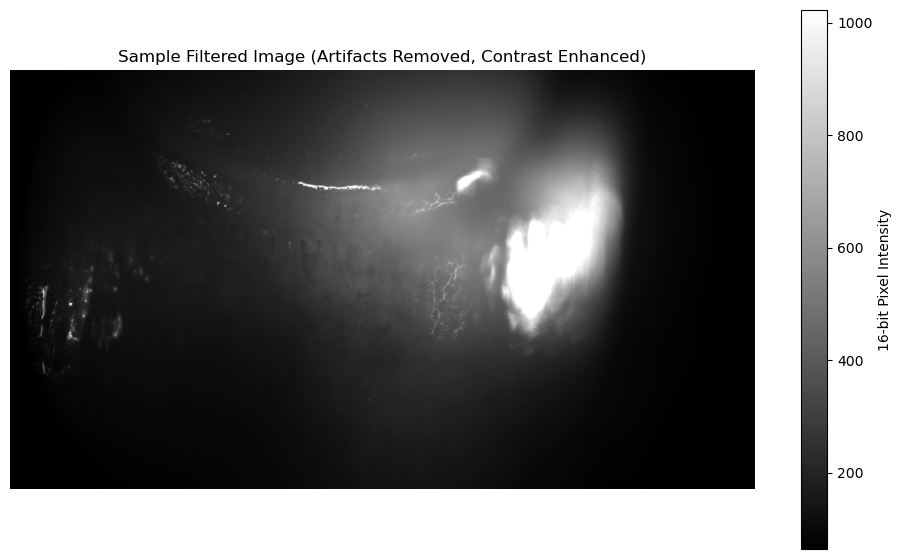

Loading and filtering raw data for: 20250620_104036_554142_p[RealtimeDefault0]_req[792]_ChiNum[791]_Mode[7]_batch[0]_MCTFE[0]_[out]_port[50]_w[4000]_h[2252]_stride[5040]_scanline[2252].raw...
   -> Successfully saved filtered image as: 20250620_104036_554142_p[RealtimeDefault0]_req[792]_ChiNum[791]_Mode[7]_batch[0]_MCTFE[0]_[out]_port[50]_w[4000]_h[2252]_stride[5040]_scanline[2252]_FILTERED.tiff
Loading and filtering raw data for: 20250620_103912_389553_p[RealtimeDefault0]_req[6376]_ChiNum[6375]_Mode[7]_batch[0]_MCTFE[0]_[out]_port[50]_w[4000]_h[2252]_stride[5040]_scanline[2252].raw...
   -> Successfully saved filtered image as: 20250620_103912_389553_p[RealtimeDefault0]_req[6376]_ChiNum[6375]_Mode[7]_batch[0]_MCTFE[0]_[out]_port[50]_w[4000]_h[2252]_stride[5040]_scanline[2252]_FILTERED.tiff
Loading and filtering raw data for: 20250620_103912_489668_p[RealtimeDefault0]_req[6379]_ChiNum[6378]_Mode[7]_batch[0]_MCTFE[0]_[out]_port[50]_w[4000]_h[2252]_stride[5040]_scanline[2252].raw...
   -

In [34]:
def filter_and_convert_raw(raw_folder, output_folder, width, height, dtype):
    """
    Loads raw binary data, applies a median filter (to remove Bayer grid AND dead pixels), 
    and saves the result as a 16-bit TIFF suitable for quantitative analysis.
    """
    processed_count = 0
    
    for filename in os.listdir(raw_folder):
        if filename.lower().endswith('.raw'):
            raw_path = os.path.join(raw_folder, filename)
            
            base_filename = os.path.splitext(filename)[0]
            tiff_filename = base_filename + '_FILTERED.tiff'
            tiff_path = os.path.join(output_folder, tiff_filename)

            print(f"Loading and filtering raw data for: {filename}...")
            
            try:
                # 1. Load the raw binary data (pure intensity map)
                data_1d = np.fromfile(raw_path, dtype=dtype)
                raw_image = data_1d.reshape((height, width))
                
                # 2. APPLY MEDIAN FILTER (Removes grid AND dead pixel noise)
                # size=3 is the best choice here.
                filtered_image = median_filter(raw_image, size=4)
                
                # 3. Save the filtered 2D array as a 16-bit grayscale TIFF
                iio.imwrite(
                    tiff_path, 
                    filtered_image,
                    photometric='minisblack'
                )
                
                processed_count += 1
                print(f"   -> Successfully saved filtered image as: {tiff_filename}")
                
                # Optional: Display a small sample to confirm smoothing
                if processed_count == 1:
                    plt.figure(figsize=(12, 7))
                    
                    # Use a percentile-based contrast enhancement for the preview
                    v_min_val = np.percentile(filtered_image, 1) 
                    v_max_val = np.percentile(filtered_image, 99.5) 
                    
                    plt.imshow(filtered_image, cmap='gray', vmin=v_min_val, vmax=v_max_val)
                    
                    plt.title("Sample Filtered Image (Artifacts Removed, Contrast Enhanced)")
                    plt.colorbar(label='16-bit Pixel Intensity')
                    plt.axis('off')
                    plt.show()

            except Exception as e:
                print(f"   -> ERROR processing {filename}: {e}")
                
    print("\n--- Filtering and Conversion Complete ---")
    print(f"Total files converted: {processed_count}")


# Run the filtering conversion
filter_and_convert_raw(RAW_FOLDER, OUTPUT_FOLDER_MEDIAN, IMAGE_WIDTH, IMAGE_HEIGHT, DATA_TYPE)

In [7]:
import os
import numpy as np

# Get the path to the first .raw file
try:
    first_raw_file = [f for f in os.listdir(RAW_FOLDER) if f.lower().endswith('.raw')][0]
    raw_path = os.path.join(RAW_FOLDER, first_raw_file)
except IndexError:
    print("Error: No .raw files found in the specified folder.")
    exit()

file_size_bytes = os.path.getsize(raw_path)

print(f"Analyzing file: {first_raw_file}")
print(f"Total File Size: {file_size_bytes} bytes")
print("-" * 30)

# Common assumption 1: 16-bit data (2 bytes per pixel)
bytes_per_pixel_16bit = np.dtype('uint16').itemsize
estimated_pixels_16bit = file_size_bytes / bytes_per_pixel_16bit

# Common assumption 2: 8-bit data (1 byte per pixel)
bytes_per_pixel_8bit = np.dtype('uint8').itemsize
estimated_pixels_8bit = file_size_bytes / bytes_per_pixel_8bit

print(f"If Data Type is uint16 (16-bit):")
if estimated_pixels_16bit == int(estimated_pixels_16bit):
    print(f"  -> Total Pixels: {int(estimated_pixels_16bit):,} (Test this first!)")
    print(f"  -> Test Square Root: {estimated_pixels_16bit**0.5:.2f}")
else:
    print("  -> File size is not evenly divisible by 2. uint16 is unlikely.")

print(f"\nIf Data Type is uint8 (8-bit):")
if estimated_pixels_8bit == int(estimated_pixels_8bit):
    print(f"  -> Total Pixels: {int(estimated_pixels_8bit):,}")
    print(f"  -> Test Square Root: {estimated_pixels_8bit**0.5:.2f}")
else:
    # This should rarely happen for simple raw binary data
    print("  -> File size is not evenly divisible by 1. Check file integrity.")

print("-" * 30)
print("Find the (Width x Height) that equals the 'Total Pixels'.")

Analyzing file: 20250620_104422_674830_p[RealtimeDefault0]_req[898]_ChiNum[897]_Mode[7]_batch[0]_MCTFE[0]_[out]_port[50]_w[4000]_h[2252]_stride[5040]_scanline[2252].raw
Total File Size: 18016000 bytes
------------------------------
If Data Type is uint16 (16-bit):
  -> Total Pixels: 9,008,000 (Test this first!)
  -> Test Square Root: 3001.33

If Data Type is uint8 (8-bit):
  -> Total Pixels: 18,016,000
  -> Test Square Root: 4244.53
------------------------------
Find the (Width x Height) that equals the 'Total Pixels'.


Debayering raw data for: 20250620_104422_674830_p[RealtimeDefault0]_req[898]_ChiNum[897]_Mode[7]_batch[0]_MCTFE[0]_[out]_port[50]_w[4000]_h[2252]_stride[5040]_scanline[2252].raw...
   -> Successfully saved debayered green channel: 20250620_104422_674830_p[RealtimeDefault0]_req[898]_ChiNum[897]_Mode[7]_batch[0]_MCTFE[0]_[out]_port[50]_w[4000]_h[2252]_stride[5040]_scanline[2252]_DEBAYERED_GREEN.tiff


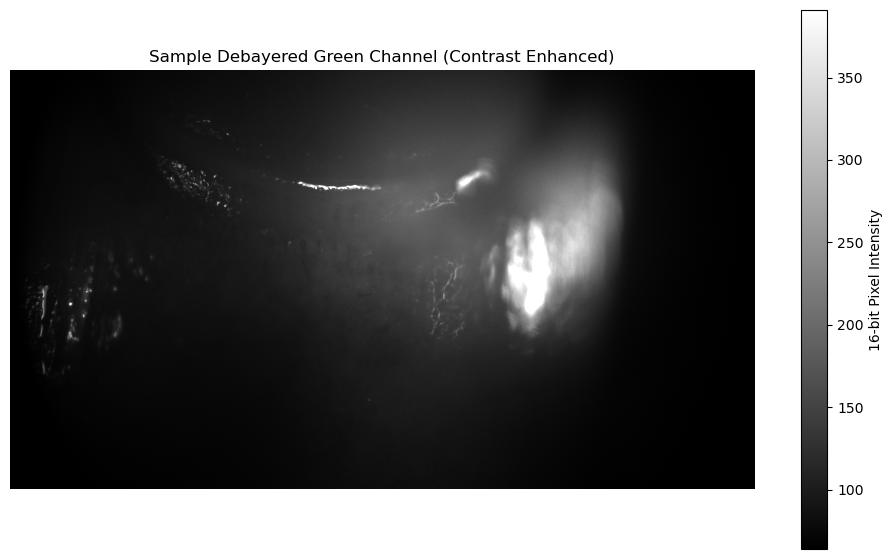

Debayering raw data for: 20250620_104036_554142_p[RealtimeDefault0]_req[792]_ChiNum[791]_Mode[7]_batch[0]_MCTFE[0]_[out]_port[50]_w[4000]_h[2252]_stride[5040]_scanline[2252].raw...
   -> Successfully saved debayered green channel: 20250620_104036_554142_p[RealtimeDefault0]_req[792]_ChiNum[791]_Mode[7]_batch[0]_MCTFE[0]_[out]_port[50]_w[4000]_h[2252]_stride[5040]_scanline[2252]_DEBAYERED_GREEN.tiff
Debayering raw data for: 20250620_103912_389553_p[RealtimeDefault0]_req[6376]_ChiNum[6375]_Mode[7]_batch[0]_MCTFE[0]_[out]_port[50]_w[4000]_h[2252]_stride[5040]_scanline[2252].raw...
   -> Successfully saved debayered green channel: 20250620_103912_389553_p[RealtimeDefault0]_req[6376]_ChiNum[6375]_Mode[7]_batch[0]_MCTFE[0]_[out]_port[50]_w[4000]_h[2252]_stride[5040]_scanline[2252]_DEBAYERED_GREEN.tiff
Debayering raw data for: 20250620_103912_489668_p[RealtimeDefault0]_req[6379]_ChiNum[6378]_Mode[7]_batch[0]_MCTFE[0]_[out]_port[50]_w[4000]_h[2252]_stride[5040]_scanline[2252].raw...
   -> Succe

In [35]:
import os
import numpy as np
import imageio.v3 as iio
import cv2  # The OpenCV library for demosaicing
from scipy.ndimage import median_filter # We still use this for noise
import matplotlib.pyplot as plt

# --- CONFIGURATION (Confirmed Parameters) ---
IMAGE_WIDTH = 4000
IMAGE_HEIGHT = 2252
DATA_TYPE = np.uint16

# --- !! CRITICAL VARIABLE: BAYER PATTERN !! ---
# You MUST choose the correct pattern for your sensor.
# The 4 possibilities are:
# cv2.COLOR_BayerBG2BGR  (Top-left pixel is Blue, then Green)
# cv2.COLOR_BayerGB2BGR  (Top-left pixel is Green, then Blue)
# cv2.COLOR_BayerRG2BGR  (Top-left pixel is Red, then Green)
# cv2.COLOR_BayerGR2BGR  (Top-left pixel is Green, then Red)
#
# Start with 'BG' or 'GR' as they are very common.
BAYER_PATTERN = cv2.COLOR_BayerBG2BGR
# ------------------------------------------------

# --- Folder Paths ---
OUTPUT_FOLDER_DEBAYERED = '../_images/RAW_debayered' # <--- SET YOUR OUTPUT FOLDER PATH
# ----------------------------------------------------------

# Create the output directory if it doesn't exist
os.makedirs(OUTPUT_FOLDER_DEBAYERED, exist_ok=True)


def debayer_and_convert_raw(raw_folder, output_folder, width, height, dtype, pattern):
    """
    Loads raw 16-bit data, applies a scientific demosaicing algorithm,
    extracts the green channel, and applies a noise-removal filter.
    """
    processed_count = 0
    
    for filename in os.listdir(raw_folder):
        if filename.lower().endswith('.raw'):
            raw_path = os.path.join(raw_folder, filename)
            
            base_filename = os.path.splitext(filename)[0]
            tiff_filename = base_filename + '_DEBAYERED_GREEN.tiff'
            tiff_path = os.path.join(output_folder, tiff_filename)

            print(f"Debayering raw data for: {filename}...")
            
            try:
                data_1d = np.fromfile(raw_path, dtype=dtype)
                raw_image = data_1d.reshape((height, width))
                bgr_image = cv2.demosaicing(raw_image, pattern)

                green_channel = bgr_image[:, :, 1]
                

                filtered_green_channel = median_filter(green_channel, size=3)

                # 5. Save the final 16-bit 1-channel grayscale TIFF
                iio.imwrite(
                    tiff_path, 
                    filtered_green_channel,
                    photometric='minisblack' # Indicates 1-channel grayscale
                )
                
                processed_count += 1
                print(f"   -> Successfully saved debayered green channel: {tiff_filename}")
                
                # Optional: Display a small sample
                if processed_count == 1:
                    plt.figure(figsize=(12, 7))
                    v_min_val = np.percentile(filtered_green_channel, 1) 
                    v_max_val = np.percentile(filtered_green_channel, 99.5) 
                    plt.imshow(filtered_green_channel, cmap='gray', vmin=v_min_val, vmax=v_max_val)
                    plt.title("Sample Debayered Green Channel (Contrast Enhanced)")
                    plt.colorbar(label='16-bit Pixel Intensity')
                    plt.axis('off')
                    plt.show()

            except Exception as e:
                print(f"   -> ERROR processing {filename}: {e}")
                
    print("\n--- Debayering and Conversion Complete ---")
    print(f"Total files converted: {processed_count}")

# Execute the conversion
debayer_and_convert_raw(RAW_FOLDER, OUTPUT_FOLDER_DEBAYERED, IMAGE_WIDTH, IMAGE_HEIGHT, DATA_TYPE, BAYER_PATTERN)
